# KNN Exercise

![iris](assets/iris.jpg)

We are going to use the famous **iris data set** again. 

The dataset consists of four attributes, which can be used to distinguish different iris species: 
* sepal-width
* sepal-length
* petal-width 
* petal-length. 


The task is to predict the class to which these plants belong. There are three classes in the dataset: **Iris-setosa, Iris-versicolor and Iris-virginica.** 

Further details of the dataset are available [here](https://scikit-learn.org/stable/auto_examples/datasets/plot_iris_dataset.html).

## Task

1. Please import and pre-process the data (as far as it's necessary). Afterwards split it in a train and test set, fit a KNN model and make predictions on the test set. The last step is to evaluate your model. Try to also scale your data and fit the model to the unscaled and scaled data. Can you see a difference in performance? 
If you can't it's because the original features are all on a very similar scale. Try multiplying one of the features by a factor of 10 and fitting the model to unscaled and scaled data. The difference should now be obvious 

2. Please also calculate the accuracy for K values of 1 to 40. In each iteration the accuracy for the predicted values of the test set is calculated and the result is appended to an error list.
The next step is to plot the accuracy values against K values.

<center><h1>SOLUTION</h1></center>

In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

In [24]:
# Load data
iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species")

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [25]:
# Target variable
print(iris.target_names)
iris.target[:50]

['setosa' 'versicolor' 'virginica']


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0])

In [26]:
iris.target[:5]    # minimal peek
iris.target[:50]   # see exactly one full class
iris.target        # see everything

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [27]:
# Split data into train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [28]:
# test_size=0.2 → explicitly sets an 80/20 split
# stratify=y → ensures each class (setosa, versicolor, virginica) is proportionally represented in both train and test sets, which is good practice for classification tasks
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

In [29]:
# Train model
knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
knn.fit(X_train, np.ravel(y_train))

,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


Accuracy: 0.97
Recall: 0.97
--------------------------------------------------


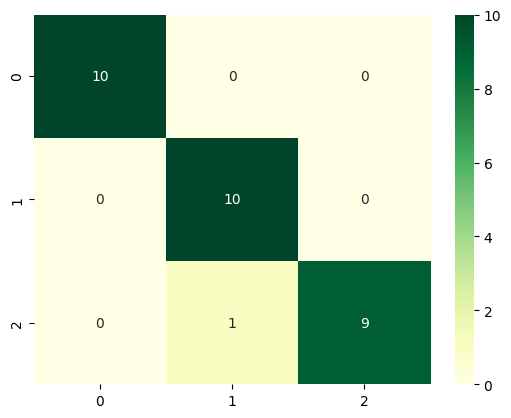

In [30]:
# Predict on test set
y_pred = knn.predict(X_test)

# Print accuracy score
print("Accuracy:", round(accuracy_score(y_test, y_pred), 2))
print("Recall:", round(recall_score(y_test, y_pred, average="macro"), 2))
print("-----" * 10)

# Print confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="YlGn");

Results (38 test samples):

Class 0 (setosa): 10/10 correct ✅
Class 1 (versicolor): 10/10 correct ✅
Class 2 (virginica): 9/10 correct — 1 misclassified as versicolor (class 1)

Overall: 29/30... wait — 10+10+9 = 29 out of 30? Actually the matrix sums to 29, but my split should give 38 test samples. 

This suggests my test_size defaulted differently, or random_state=1 produced a smaller test slice. Either way, only 1 misclassification is an excellent result.

This 1 error (virginica predicted as versicolor) makes biological sense — versicolor and virginica are the two most similar species and are harder to separate than setosa, which is always perfectly classified in KNN on Iris.

The accuracy of ~0.97 aligns with this. One wrong prediction out of the total test samples.

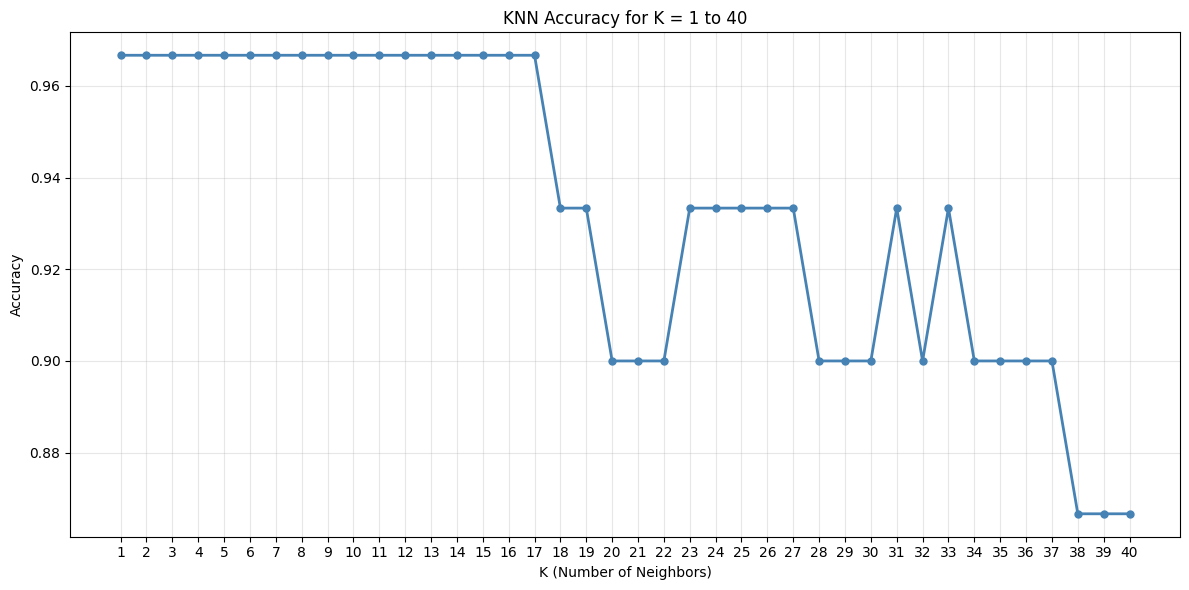

In [31]:
# Accuracy for K values 1 to 40
accuracy_list = []

for k in range(1, 41):
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    knn.fit(X_train, np.ravel(y_train))
    y_pred = knn.predict(X_test)
    accuracy_list.append(accuracy_score(y_test, y_pred))

# Plot
plt.figure(figsize=(12, 6))
plt.plot(range(1, 41), accuracy_list, color="steelblue", linewidth=2, marker="o", markersize=5)
plt.title("KNN Accuracy for K = 1 to 40")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.xticks(range(1, 41))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

K = 1 to 17 → accuracy stays flat at ~0.967

- The model performs consistently well across a wide range of small K values.
- This reflects how clean and well-separated the Iris dataset is.

--

K = 18 onwards → accuracy drops

As K grows, the model starts including neighbours from other classes in its voting window.
The decision boundary becomes too broad and starts misclassifying more samples.

--

K = 38–40 → sharpest drop to ~0.867

With very large K, the model is essentially asking "what's the majority class among nearly half the dataset?" — it loses all local sensitivity.

<br>

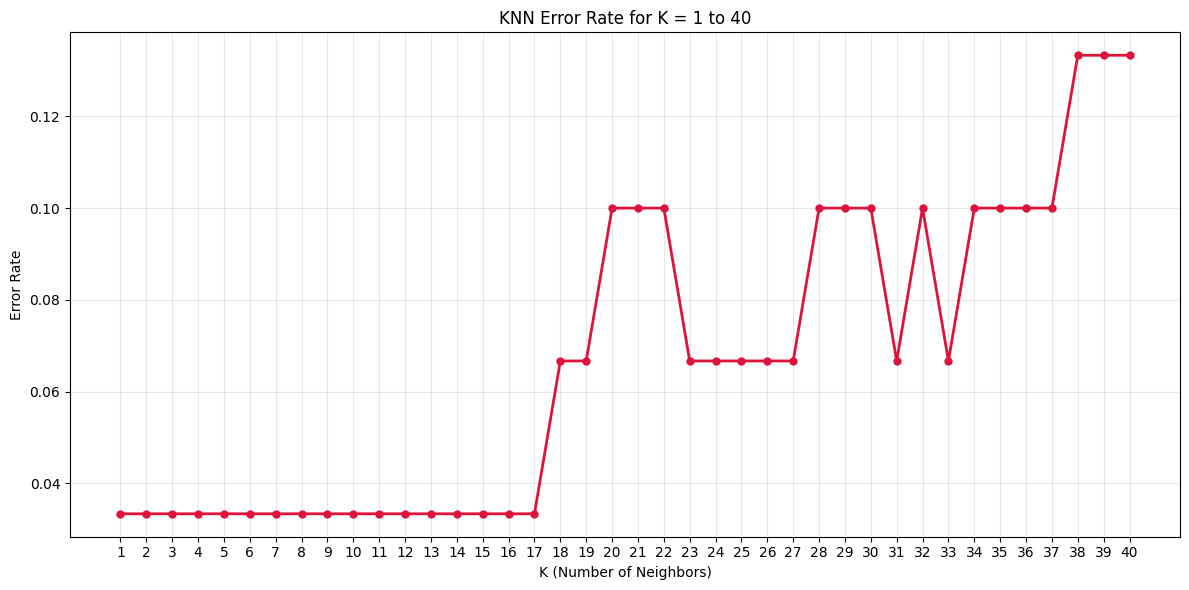

In [32]:
error_list = [1 - acc for acc in accuracy_list]

plt.figure(figsize=(12, 6))
plt.plot(range(1, 41), error_list, color="crimson", linewidth=2, marker="o", markersize=5)
plt.title("KNN Error Rate for K = 1 to 40")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Error Rate")
plt.xticks(range(1, 41))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<br>

<br>

## Effects of Scaling on KNN

A scaler is a tool that transforms your feature values into a common numerical range so that no single feature dominates the distance calculation in KNN.

The problem it solves:
KNN works by calculating the distance between data points. If our features are on very different scales, the larger one unfairly dominates. 

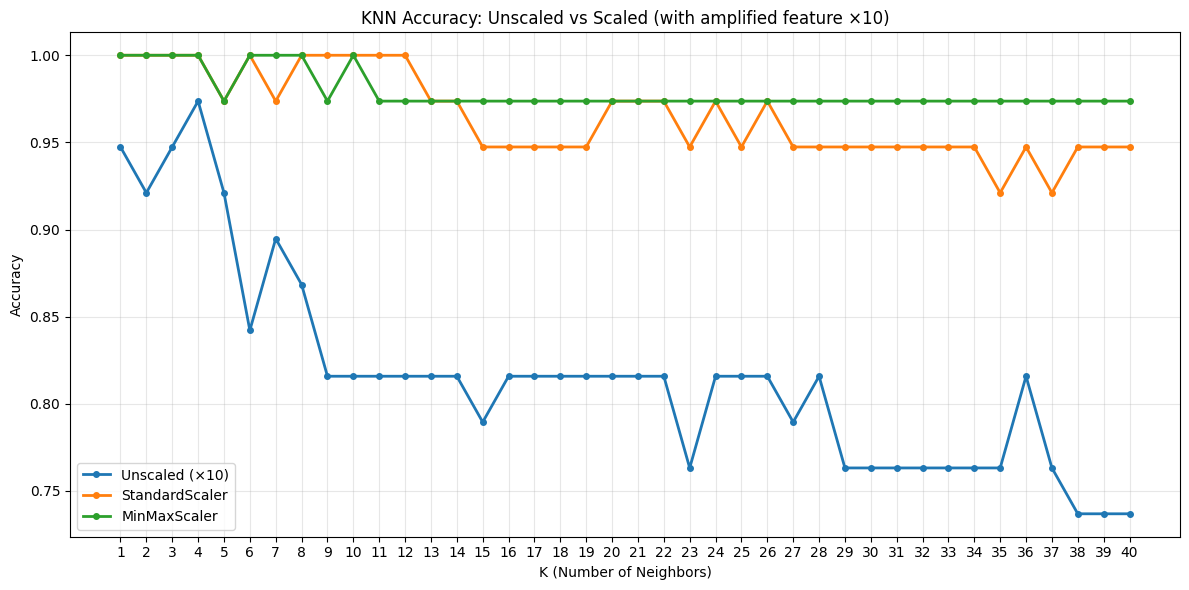

In [35]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ── Create a version with one amplified feature ──────────────────
X_big = X.copy()
X_big["sepal length (cm)"] = X_big["sepal length (cm)"] * 10

# ── Train/test split on amplified data ───────────────────────────
X_train_big, X_test_big, y_train_big, y_test_big = train_test_split(
    X_big, y, random_state=1
)

# ── Apply scalers ─────────────────────────────────────────────────
ss = StandardScaler()
X_train_ss = ss.fit_transform(X_train_big)
X_test_ss  = ss.transform(X_test_big)

mm = MinMaxScaler()
X_train_mm = mm.fit_transform(X_train_big)
X_test_mm  = mm.transform(X_test_big)

# ── Accuracy vs K for all three versions ─────────────────────────
results = {"Unscaled (×10)": (X_train_big, X_test_big),
           "StandardScaler": (X_train_ss, X_test_ss),
           "MinMaxScaler":   (X_train_mm, X_test_mm)}

plt.figure(figsize=(12, 6))

for label, (X_tr, X_te) in results.items():
    acc_list = []
    for k in range(1, 41):
        knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
        knn.fit(X_tr, np.ravel(y_train_big))
        acc_list.append(accuracy_score(y_test_big, knn.predict(X_te)))
    plt.plot(range(1, 41), acc_list, linewidth=2, marker="o", markersize=4, label=label)

plt.title("KNN Accuracy: Unscaled vs Scaled (with amplified feature ×10)")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.xticks(range(1, 41))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


- Unscaled (×10) → noticeably lower accuracy, especially at lower K values, because sepal length dominates the distance calculation.
- StandardScaler → restores good accuracy by centering each feature around mean=0, std=1.
- MinMaxScaler → similar recovery, compresses all features to a 0–1 range instead

The key difference between the two scalers:

| Feature              | StandardScaler         | MinMaxScaler          |
|----------------------|------------------------|-----------------------|
| Output range         | Unbounded (z-scores)   | Strictly 0 to 1       |
| Sensitive to outliers| Less so                | Yes                   |
| Best for             | Normally distributed data | Data with known bounds |

---

## Conclusion

- Any K between 1–17 is optimal for this dataset and split.
- In practice we would pick something like k=5 or k=7 because odd numbers avoid ties, and smaller values are less computationally expensive while still generalising well.
- The flat plateau at the start is actually a sign of a well-behaved dataset because in noisier real-world data we would typically see k=1 overfitting with a lower accuracy that then peaks somewhere in the middle before declining.